In [ ]:
# Title: 01_McKay_BayesAge_calibration.ipynb
# Author: Lajoyce Mboning
# Date:2025
# Related publication: Emma K. Costa, and Jingxun Chen, in prep


# Description - Run the BayesAge clock on McKay et al

# Set Up

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from numpy import arange
from numpy import absolute
from numpy import mean
from numpy import std
import numpy as np
from scipy import stats
from sklearn.metrics import mean_absolute_error as mae
import statsmodels.api as sm
from scipy.stats import spearmanr
lowess = sm.nonparametric.lowess
from scipy.stats import poisson
from scipy.stats import pearsonr
from datetime import datetime
import time
import random
import itertools

In [ ]:
#allow Google CoLab to have access to your drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# set working dir
# Get current notebook's directory
notebook_dir = '/content/drive/My Drive/african_killifish_atlas/revisions/CodeCheck_revisions/McKay_model_outputs/BayesAge/'

# Set working directory (here it's just confirming it's already set)
os.chdir(notebook_dir)

In [ ]:
# List of directories you want to create
dirs_to_create = [
    "./reference/",
    "./predictions/",
    "./gene_sets/",
    "./plots/",
    "./predictions_exhaustive/",
    "./reference_exhaustive/"
]


for d in dirs_to_create:
    os.makedirs(d, exist_ok=True)  # exist_ok=True won't raise an error if it already exists

In [ ]:
def transcriptome_reference(training_matrix,
                        reference_name,
                        output_path="./predictions/",
                        age_prediction="list",
                        age_list=[],
                        min_age=-20,
                        max_age=100,
                        age_step=1,
                        tau=0.7,
                        ):

    start_time = time.time()

    training_cv_df = training_matrix

    training_df_frequency = training_cv_df.iloc[:,:-1]

    #print(training_df_frequency)

    training_df_frequency = training_df_frequency.div(training_df_frequency.sum(axis=1), axis=0)

    genes = training_cv_df.iloc[:,:-1].columns.tolist()

    age_steps = np.arange(min_age, max_age + age_step, age_step)

    # Age values from the reference data
    age_training = training_cv_df["age"].values.flatten()

    final_training_matrix = []

    if age_prediction == "list":

        for gene in genes:
            # Frequency level of current gene
            gene_frequency = training_df_frequency[gene].values.flatten()

            # Perform lowess smoothing
            predicted_frequency_levels = lowess(gene_frequency, age_training, xvals=age_list, frac=tau)

            # Calculate Spearman rank correlation
            rho, p = spearmanr(age_training, gene_frequency)

            spearman_rank = rho

            p_value = p

            final_gene_frequency_tuple = (gene, ) + tuple(predicted_frequency_levels) + (spearman_rank, p_value)

            final_training_matrix.append(final_gene_frequency_tuple)

        df_columns = ["Gene"] + [str(num) for num in age_list] + ["spearman_rank", "p_value"]

    elif age_prediction == "steps":

        for gene in genes:
            # Frequency level of current gene
            gene_frequency = training_df_frequency[gene].values.flatten()

            # Perform lowess smoothing
            predicted_frequency_levels = lowess(gene_frequency, age_training, xvals=age_steps, frac=tau)

            # Calculate Spearman rank correlation
            rho, p = spearmanr(age_training, gene_frequency)

            spearman_rank = rho

            p_value = p

            final_gene_frequency_tuple = (gene, ) + tuple(predicted_frequency_levels) + (spearman_rank, p_value)

            final_training_matrix.append(final_gene_frequency_tuple)

        df_columns = ["Gene"] + [str(num) for num in age_steps] + ["spearman_rank", "p_value"]


    df = pd.DataFrame(final_training_matrix, columns=df_columns)
    df.set_index("Gene", inplace=True)

    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)

    # Save the DataFrame to a TSV file
    df.to_csv(os.path.join(output_path, reference_name), sep="\t")
    print(f"\nReference model dataset written to '{os.path.join(output_path, reference_name)}'")

    number_of_samples = training_cv_df.shape[0]

    # Write report file detailing input matrix
    report_file_path = os.path.join(output_path, f'{reference_name}.report.txt')
    with open(report_file_path, 'w') as writer:
        writer.write("BayesAge reference report for %s\n" % reference_name)
        now = datetime.now()
        write_datetime = now.strftime("%m/%d/%Y %H:%M:%S")
        writer.write("Reference file created: %s\n\n" % write_datetime)
        writer.write("Number of input samples = %s\n" % number_of_samples)
        writer.write("Number of input Genes = %s\n" % len(genes))
        if age_prediction == "list":
            writer.write("Predictions made for ages: %s\n" % age_list)
        elif age_prediction == "steps":
            writer.write("Predictions made for age steps from %s to %s with step %s\n" % (min_age, max_age, age_step))

    print(f"Report file generated at '{report_file_path}'")
    print("-----------------------------------------------------\n\n")

    end_time = time.time()
    elapsed_time = end_time - start_time
    print("\nTime to run construct reference: %0.3f seconds" % elapsed_time)
    print("\nThe reference is constructed and saved!")

    return df  # Optionally return the DataFrame

# Load & format atlas data

In [ ]:
# load raw counts
df_unnorm = pd.read_csv("../../AtlasFiles_forLajoyce_240507/Counts_Atlas_allbatches_merged_v3.csv")
df_unnorm.head(3)

,Unnamed: 0,A1_1,A1_2,A10_1,A10_2,A11_1,A11_2,A12_1,A12_2,A13_1,...,P4_2,P5_1,P5_2,P6_1,P6_2,P7_1,P7_2,P8_2,P9_1,P9_2
0,a1cf,21686,52,5891,6,7544,18,10043,9,0,...,12,45920,3113,9682,4020,37522,1383,36,7855,14
1,aaas,623,585,1108,720,824,1072,1004,611,192,...,484,310,143,336,487,178,148,735,1383,717
2,aacs,1980,502,266,1913,238,2252,308,1614,56,...,1061,6587,291,3347,552,329,178,1124,382,1232


In [ ]:
df_unnorm.rename(columns={"Unnamed: 0": "sample"}, inplace=True)
df_unnorm.set_index("sample", inplace=True)
df_unnorm.head(3)

,A1_1,A1_2,A10_1,A10_2,A11_1,A11_2,A12_1,A12_2,A13_1,A13_2,...,P4_2,P5_1,P5_2,P6_1,P6_2,P7_1,P7_2,P8_2,P9_1,P9_2
sample,,,,,,,,,,,,,,,,,,,,,
a1cf,21686,52,5891,6,7544,18,10043,9,0,30,...,12,45920,3113,9682,4020,37522,1383,36,7855,14
aaas,623,585,1108,720,824,1072,1004,611,192,591,...,484,310,143,336,487,178,148,735,1383,717
aacs,1980,502,266,1913,238,2252,308,1614,56,227,...,1061,6587,291,3347,552,329,178,1124,382,1232


In [ ]:
df_unnorm = df_unnorm.T
df_unnorm.head(3)

sample,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_1,21686,623,1980,523,200,802,1242,1224,562,577,...,829,161,1014,220,1560,42,515,3018,1422,325
A1_2,52,585,502,537,709,674,1385,2329,652,646,...,1113,92,963,153,1118,27,966,3871,275,364
A10_1,5891,1108,266,676,233,835,1374,809,716,778,...,635,156,1650,137,1370,380,662,3191,498,477


In [ ]:
# load metadata
df_metadata = pd.read_csv("../../AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata.head(3)

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.reset_index()

,index,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,...,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,...,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,...,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,...,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN
3,3,A10_2,J_1A_14,M,1A,75,11/22/21,9/8/21,SpinalCord,NaN,...,SpinalCord_1,EC,RNA423,2,A10,A10,A10_2,NaN,NaN,NaN
4,4,A11_1,J_1A_22,M,1A,47,10/25/21,9/8/21,Kidney,NaN,...,Kidney_2,JC,R274,1,A11,A11,A11_1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,672,P7_1,J_1A_25,M,1A,103,12/20/21,9/8/21,Liver,NaN,...,Liver_1,IG,RNA689,1,P7,P7,P7_1,NaN,NaN,NaN
673,673,P7_2,P_1B_1,F,1B,77,12/6/21,9/20/21,Fat,4/13/23,...,Fat_3,EC,RNA566,2,P7,P7,P7_2,NaN,NaN,NaN
674,674,P8_2,J_1A_25,M,1A,103,12/20/21,9/8/21,Eye,NaN,...,Eye_1,MRW,642,2,P8,P8,P8_2,NaN,NaN,NaN
675,675,P9_1,J_1B_2,M,1B,49,11/8/21,9/20/21,Kidney,NaN,...,Kidney_1,JC,R257,1,P9,P9,P9_1,NaN,NaN,NaN


In [ ]:
df_metadata.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata.head(3)

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.set_index("sample", inplace=True)
df_metadata.head(2)

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
sample,,,,,,,,,,,,,,,,,,,
A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN


In [ ]:
# Merge based on index
combined_df = pd.concat([df_unnorm, df_metadata[['sex', 'tissue', 'age_days']]], axis=1)
combined_df.rename(columns={"age_days": "age"}, inplace=True)
combined_df.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A1_1,21686,623,1980,523,200,802,1242,1224,562,577,...,220,1560,42,515,3018,1422,325,F,Gut,155
A1_2,52,585,502,537,709,674,1385,2329,652,646,...,153,1118,27,966,3871,275,364,M,Bone,78
A10_1,5891,1108,266,676,233,835,1374,809,716,778,...,137,1370,380,662,3191,498,477,M,Kidney,133


# Load & format ALDR data

In [ ]:
#raw counts from intervention dataset
df_intervention = pd.read_csv("../../Data_from_Others/ALDR/GSE216369_Counts_ALDR_220325.csv")
df_intervention.head(3)

,f_AL_L_1,m_AL_L_1,f_AL_BR_1,m_DR_L_1,f_DR_BR_1,f_AL_L_2,f_DR_L_1,f_AL_BR_2,m_AL_BR_1,m_DR_BR_1,...,f_AL_L_4,f_DR_L_3,m_AL_L_3,m_AL_BR_4,f_AL_BR_4,m_DR_BR_4,m_DR_L_4,f_DR_BR_4,f_DR_L_4,m_AL_L_4
LOC107375582,0,0,4,0,11,0,0,4,6,15,...,0,0,0,0,3,0,0,10,0,0
LOC107388276,0,5,317,0,228,0,0,398,286,405,...,0,0,2,101,369,163,0,257,0,6
LOC107382448,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_intervention = df_intervention.T
df_intervention.head(2)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107397029,LOC107377691,...,LOC107393324,chp1,LOC107392884,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249
f_AL_L_1,0,0,1,176,142,8,0,94,0,385,...,2,1369,0,771,2,559,0,20,38,77
m_AL_L_1,0,5,0,34,372,22,0,113,0,406,...,0,2628,0,759,8,485,2,18,4,20


In [ ]:
# Parse the index and extract components
df_intervention[['sex', 'treatment', 'tissue', 'replicate']] = df_intervention.index.to_series().str.extract(r'^([^_]+)_([^_]+)_([^_]+)_([^_]+)$')
df_intervention.head(2)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107397029,LOC107377691,...,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,sex,treatment,tissue,replicate
f_AL_L_1,0,0,1,176,142,8,0,94,0,385,...,2,559,0,20,38,77,f,AL,L,1
m_AL_L_1,0,5,0,34,372,22,0,113,0,406,...,8,485,2,18,4,20,m,AL,L,1


In [ ]:
df_intervention['age'] = 63
df_intervention.head(2)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107397029,LOC107377691,...,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,sex,treatment,tissue,replicate,age
f_AL_L_1,0,0,1,176,142,8,0,94,0,385,...,559,0,20,38,77,f,AL,L,1,63
m_AL_L_1,0,5,0,34,372,22,0,113,0,406,...,485,2,18,4,20,m,AL,L,1,63


In [ ]:
df_intervention['tissue'] = df_intervention['tissue'].replace('L', 'Liver')
df_intervention['sex'] = df_intervention['sex'].replace('m', 'M')
df_intervention['sex'] = df_intervention['sex'].replace('f', 'F')

select_tissue = 'Liver'

# Male - ALDR

### Define training and test sets

In [ ]:
df_intervention_male = df_intervention.loc[(df_intervention.iloc[:, -3] == select_tissue) &
    (df_intervention.iloc[:, -5] == 'M')]
df_intervention_male

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107397029,LOC107377691,...,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,sex,treatment,tissue,replicate,age
m_AL_L_1,0,5,0,34,372,22,0,113,0,406,...,485,2,18,4,20,M,AL,Liver,1,63
m_DR_L_1,0,0,0,16,375,44,0,88,0,294,...,667,4,34,28,26,M,DR,Liver,1,63
m_AL_L_2,0,0,0,26,229,10,2,119,0,302,...,479,22,18,6,61,M,AL,Liver,2,63
m_DR_L_2,2,0,0,14,491,70,22,126,0,298,...,747,8,44,10,30,M,DR,Liver,2,63
m_DR_L_3,2,0,0,4,308,18,0,92,0,240,...,404,2,6,14,24,M,DR,Liver,3,63
m_AL_L_3,0,2,0,0,240,6,0,67,0,267,...,597,10,40,26,34,M,AL,Liver,3,63
m_DR_L_4,0,0,0,2,373,8,0,90,0,400,...,451,2,36,28,17,M,DR,Liver,4,63
m_AL_L_4,0,6,0,29,349,12,2,66,0,301,...,699,8,46,6,55,M,AL,Liver,4,63


In [ ]:
random.seed(123)

#select two AL samples for calibration
all_samples = df_intervention_male.index
AL_samples = [s for s in all_samples if s in df_intervention_male.index and df_intervention_male.loc[s, 'treatment'] == 'AL']

# Randomly sample 2 from each
random_AL = random.sample(AL_samples, 2)

#select your training samples
select_train_samples = random_AL

df_intervention_train = df_intervention.loc[
    df_intervention.index.isin(select_train_samples)
]

df_intervention_train

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107397029,LOC107377691,...,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,sex,treatment,tissue,replicate,age
m_AL_L_1,0,5,0,34,372,22,0,113,0,406,...,485,2,18,4,20,M,AL,Liver,1,63
m_AL_L_2,0,0,0,26,229,10,2,119,0,302,...,479,22,18,6,61,M,AL,Liver,2,63


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['m_DR_L_1', 'm_DR_L_2', 'm_DR_L_3', 'm_AL_L_3', 'm_DR_L_4', 'm_AL_L_4']

In [ ]:
df_intervention_test = df_intervention.loc[
    df_intervention.index.isin(test_samples)
]

df_intervention_test.head(3)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107397029,LOC107377691,...,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,sex,treatment,tissue,replicate,age
m_DR_L_1,0,0,0,16,375,44,0,88,0,294,...,667,4,34,28,26,M,DR,Liver,1,63
m_DR_L_2,2,0,0,14,491,70,22,126,0,298,...,747,8,44,10,30,M,DR,Liver,2,63
m_DR_L_3,2,0,0,4,308,18,0,92,0,240,...,404,2,6,14,24,M,DR,Liver,3,63


### Male - transcriptome reference

In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
    (combined_df.iloc[:, -3] == 'M')
]
tissue_df_counts['treatment'] = 'AL'
tissue_df_counts.head(5)

/tmp/ipython-input-3975167852.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tissue_df_counts['treatment'] = 'AL'


,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
A5_1,36508,206,3342,296,14,375,356,1593,339,202,...,414,0,185,928,108,162,M,Liver,134,AL
A8_1,56721,239,1240,467,30,416,444,1032,402,261,...,470,8,229,1014,153,168,M,Liver,133,AL
B7_1,46082,190,5874,288,30,465,555,1129,332,306,...,576,2,235,1049,250,243,M,Liver,133,AL
C5_1,41639,254,8813,231,22,423,336,1167,313,270,...,422,8,174,852,86,159,M,Liver,162,AL
C7_1,46991,267,3752,349,38,556,637,1162,378,377,...,327,6,223,1268,156,190,M,Liver,152,AL


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
m_AL_L_1,31703,180,5097,448,86,555,334,1150,436,558,...,734,16,170,756,42,70,M,Liver,63,AL
m_AL_L_2,24442,323,1682,676,102,753,165,1157,468,572,...,1388,92,172,481,10,70,M,Liver,63,AL


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
A5_1,36508,206,3342,296,14,375,356,1593,339,202,...,414,0,185,928,108,162,M,Liver,134,AL
A8_1,56721,239,1240,467,30,416,444,1032,402,261,...,470,8,229,1014,153,168,M,Liver,133,AL
B7_1,46082,190,5874,288,30,465,555,1129,332,306,...,576,2,235,1049,250,243,M,Liver,133,AL


In [ ]:
#check cols ordered the same
df_intervention_test = df_intervention_test[tissue_df_counts.columns]
df_intervention_test.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
m_DR_L_1,32047,184,1197,609,60,672,229,1225,406,576,...,924,6,222,733,44,88,M,Liver,63,DR
m_DR_L_2,25966,163,1583,537,54,726,316,1658,703,684,...,2235,0,224,1262,107,112,M,Liver,63,DR


In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[47, 49, 52, 63, 75, 77, 78, 102, 103, 133, 134, 147, 152, 161, 162]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-1,-3, -4]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_1,36508,206,3342,296,14,375,356,1593,339,202,...,25,262,36,414,0,185,928,108,162,134
A8_1,56721,239,1240,467,30,416,444,1032,402,261,...,22,319,52,470,8,229,1014,153,168,133


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./reference/liver_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name="killifish_liver_reference_male",
                            output_path="./reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference/killifish_liver_reference_male'
Report file generated at './reference/killifish_liver_reference_male.report.txt'
-----------------------------------------------------



Time to run construct reference: 110.584 seconds

The reference is constructed and saved!


,47,48,49,50,51,52,53,54,55,56,...,155,156,157,158,159,160,161,162,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,1.150277e-03,1.154490e-03,1.158739e-03,1.163022e-03,1.167338e-03,1.171683e-03,1.176056e-03,1.180454e-03,1.184875e-03,1.189316e-03,...,1.504283e-03,1.504439e-03,1.504567e-03,1.504665e-03,1.504733e-03,1.504769e-03,1.504772e-03,1.504741e-03,0.421583,0.014544
aaas,9.865943e-06,9.814706e-06,9.763724e-06,9.712979e-06,9.662436e-06,9.612059e-06,9.561814e-06,9.511687e-06,9.461670e-06,9.411752e-06,...,8.547603e-06,8.586555e-06,8.625843e-06,8.665442e-06,8.705328e-06,8.745478e-06,8.785867e-06,8.826475e-06,-0.086126,0.633670
aacs,1.943848e-04,1.905137e-04,1.866675e-04,1.828479e-04,1.790565e-04,1.752945e-04,1.715629e-04,1.678618e-04,1.641908e-04,1.605497e-04,...,1.582085e-04,1.605989e-04,1.629967e-04,1.654020e-04,1.678150e-04,1.702357e-04,1.726641e-04,1.751003e-04,0.147789,0.411779
aadat,1.260620e-05,1.255519e-05,1.250418e-05,1.245317e-05,1.240217e-05,1.235116e-05,1.230014e-05,1.224912e-05,1.219811e-05,1.214713e-05,...,9.362829e-06,9.355673e-06,9.348581e-06,9.341531e-06,9.334498e-06,9.327460e-06,9.320396e-06,9.313284e-06,-0.621316,0.000114
aaed1,1.404189e-06,1.400038e-06,1.395867e-06,1.391678e-06,1.387470e-06,1.383239e-06,1.378986e-06,1.374711e-06,1.370419e-06,1.366114e-06,...,8.599384e-07,8.609598e-07,8.621097e-07,8.633852e-07,8.647834e-07,8.663017e-07,8.679372e-07,8.696871e-07,-0.412703,0.016992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,9.552364e-07,9.393247e-07,9.235179e-07,9.078192e-07,8.922306e-07,8.767541e-07,8.613910e-07,8.461400e-07,8.309987e-07,8.159647e-07,...,9.344493e-08,9.103548e-08,8.866710e-08,8.634005e-08,8.405454e-08,8.181076e-08,7.960887e-08,7.744892e-08,-0.462314,0.006753
zyg11b,7.279109e-06,7.279593e-06,7.280063e-06,7.280515e-06,7.280937e-06,7.281311e-06,7.281621e-06,7.281853e-06,7.281990e-06,7.282018e-06,...,6.808288e-06,6.805728e-06,6.803194e-06,6.800685e-06,6.798198e-06,6.795731e-06,6.793282e-06,6.790849e-06,-0.173258,0.334929
zyx,4.436712e-05,4.428549e-05,4.420409e-05,4.412290e-05,4.404189e-05,4.396101e-05,4.388021e-05,4.379945e-05,4.371868e-05,4.363786e-05,...,3.618844e-05,3.623399e-05,3.628189e-05,3.633203e-05,3.638433e-05,3.643868e-05,3.649498e-05,3.655313e-05,-0.213473,0.232935


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-1,-2,-3, -4]], axis=1)
df_intervention_test_counts.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
m_DR_L_1,32047,184,1197,609,60,672,229,1225,406,576,...,56,52,100,149,924,6,222,733,44,88
m_DR_L_2,25966,163,1583,537,54,726,316,1658,703,684,...,94,37,242,120,2235,0,224,1262,107,112
m_DR_L_3,24426,116,2656,589,80,543,152,1355,503,551,...,38,49,72,192,347,2,96,428,56,32


In [ ]:
gene_number = 20
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./reference/killifish_liver_reference_male", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    gene_num = "".join([str(gene_number), "genes"])
    out_file_prefix = 'ALDR_male_pred'
    out_file_name = "_".join([out_file_prefix, gene_num])
    output_path = './gene_sets'
    df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

print(df_intervention_test_pred)

List has been written to ALDR_male_pred_20genes
List has been written to ALDR_male_pred_20genes
List has been written to ALDR_male_pred_20genes
List has been written to ALDR_male_pred_20genes
List has been written to ALDR_male_pred_20genes
List has been written to ALDR_male_pred_20genes
         prediction
m_DR_L_1       51.0
m_DR_L_2       50.0
m_DR_L_3       69.0
m_AL_L_3       78.0
m_DR_L_4       64.0
m_AL_L_4       91.0


In [ ]:
df_intervention_test_pred["treatment"] = df_intervention_test["treatment"].tolist()
df_intervention_test_pred

,prediction,treatment
m_DR_L_1,51.0,DR
m_DR_L_2,50.0,DR
m_DR_L_3,69.0,DR
m_AL_L_3,78.0,AL
m_DR_L_4,64.0,DR
m_AL_L_4,91.0,AL


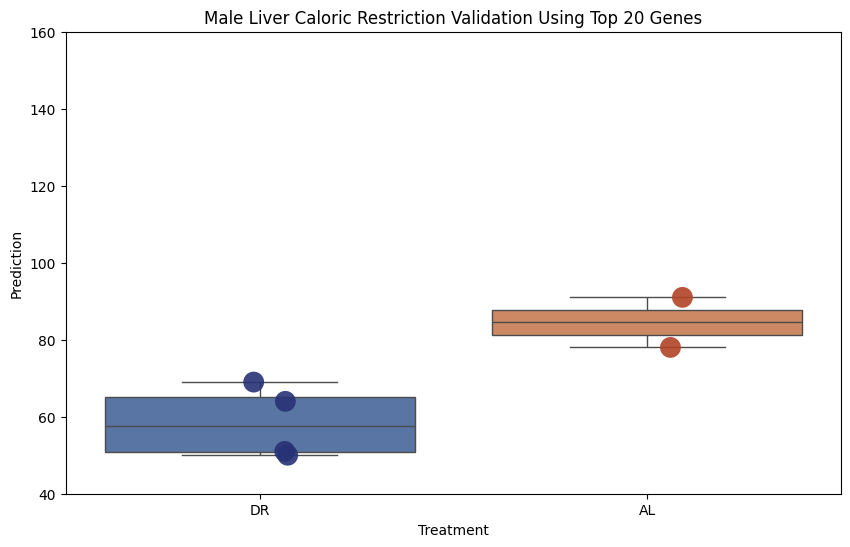

In [ ]:
# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='treatment', y='prediction', hue='treatment', data=df_intervention_test_pred, palette='deep', showfliers = False)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='treatment',
    y='prediction',
    hue='treatment',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join(['Male Liver Caloric Restriction Validation Using Top ', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

# Show the plot
plt.show()

In [ ]:
df_intervention_test_pred.to_csv("./df_prediction_BayesAge_sex_specific_mckay_male.csv", sep="\t")

### Male - rotate training samples

In [ ]:
#------------------------------------------------------------
# Sample selection setup
#------------------------------------------------------------
#select two AL samples for calibration
all_samples = df_intervention_male.index
AL_samples = [s for s in all_samples if s in df_intervention_male.index and df_intervention_male.loc[s, 'treatment'] == 'AL']

# Create all combinations of AL samples
AL_combos = list(itertools.combinations(AL_samples, 2))

#------------------------------------------------------------
# Loop through all young-old combinations
#------------------------------------------------------------
for AL_combo in AL_combos:

  combo_id = f"{'_'.join(map(str, AL_combo))}"
  print(f"\nRunning combo: {combo_id}")

  # Select samples for training
  select_train_samples = list(AL_combo)
  df_intervention_train = df_intervention_male.loc[select_train_samples]
  df_intervention_train = df_intervention_train[tissue_df_counts.columns]  # match columns

  # Combine with atlas
  atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
  age_steps = sorted(atlas_plus_intervention["age"].value_counts().index.tolist())

  atlas_plus_intervention = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-1, -3, -4]], axis=1)

  # Get test set
  test_samples = [s for s in df_intervention_male.index if s not in select_train_samples]
  df_intervention_test = df_intervention_male.loc[test_samples]
  df_intervention_test_counts = df_intervention_test.drop(
      df_intervention_test.columns[[-2, -3, -4, -5]], axis=1
  )

  #check cols ordered the same
  df_intervention_test_counts = df_intervention_test_counts[atlas_plus_intervention.columns]
  df_intervention_test_counts.head(2)

  # Save per-sample reference files
  for sample in atlas_plus_intervention.index:
      atlas_plus_intervention.drop(sample).to_csv(
          f"./reference/liver_sample_{sample}_{combo_id}.csv", sep="\t"
      )

  new_age_steps = np.arange(min(age_steps), max(age_steps) + 1, 1)


  # Run transcriptome_reference (assuming it handles saving internally)
  transcriptome_reference(
      training_matrix=atlas_plus_intervention,
      reference_name=f"killifish_liver_ref_male_{combo_id}",
      output_path="./reference_exhaustive/",
      age_prediction="list",
      age_list=new_age_steps,
      min_age=1,
      max_age=24,
      age_step=1,
      tau=0.7
  )


  # Run predictions for a single gene number or loop over multiple
  for gene_number in range(5, 51, 5):
      df_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])
      reference_df = pd.read_csv(
          f"./reference_exhaustive/killifish_liver_ref_male_{combo_id}", sep="\t", index_col=0
      )
      top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

      for sample in df_intervention_test.index:
          total_reads = df_intervention_test_counts.loc[sample].sum()
          log_sums = []
          for age in new_age_steps:
              logP = []
              for gene in top_genes:
                  freq = max(reference_df.loc[gene, str(age)], 1e-10)
                  mu = freq * total_reads
                  obs = df_intervention_test_counts.loc[sample, gene]
                  p = max(poisson.pmf(obs, mu), 0.001)
                  logP.append(np.log(p))
              log_sums.append(np.sum(logP))

          pred_age = round(float(new_age_steps[np.argmax(log_sums)]), 2)
          df_pred.loc[sample, "prediction"] = pred_age

      # Add metadata and save
      df_pred["treatment"] = df_intervention_test["treatment"]

      # Save prediction results
      df_pred.to_csv(
          f"./predictions_exhaustive/male_pred_top_{gene_number}_{combo_id}.tsv", sep="\t"
      )



Running combo: m_AL_L_1_m_AL_L_2


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_liver_ref_male_m_AL_L_1_m_AL_L_2'
Report file generated at './reference_exhaustive/killifish_liver_ref_male_m_AL_L_1_m_AL_L_2.report.txt'
-----------------------------------------------------



Time to run construct reference: 115.926 seconds

The reference is constructed and saved!

Running combo: m_AL_L_1_m_AL_L_3


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_liver_ref_male_m_AL_L_1_m_AL_L_3'
Report file generated at './reference_exhaustive/killifish_liver_ref_male_m_AL_L_1_m_AL_L_3.report.txt'
-----------------------------------------------------



Time to run construct reference: 113.676 seconds

The reference is constructed and saved!

Running combo: m_AL_L_1_m_AL_L_4


...


Reference model dataset written to './reference_exhaustive/killifish_liver_ref_male_m_AL_L_2_m_AL_L_3'
Report file generated at './reference_exhaustive/killifish_liver_ref_male_m_AL_L_2_m_AL_L_3.report.txt'
-----------------------------------------------------



Time to run construct reference: 114.429 seconds

The reference is constructed and saved!

Running combo: m_AL_L_2_m_AL_L_4


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_liver_ref_male_m_AL_L_2_m_AL_L_4'
Report file generated at './reference_exhaustive/killifish_liver_ref_male_m_AL_L_2_m_AL_L_4.report.txt'
-----------------------------------------------------



Time to run construct reference: 110.785 seconds

The reference is constructed and saved!

Running combo: m_AL_L_3_m_AL_L_4


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_liver_ref_male_m_AL_L_3_m_AL_L_4'
Report file generated at './reference_exhaustive/killifish_liver_ref_male_m_AL_L_3_m_AL_L_4.report.txt'
-----------------------------------------------------



Time to run construct reference: 118.872 seconds

The reference is constructed and saved!


# Female - ALDR

In [ ]:
df_intervention_female = df_intervention.loc[(df_intervention.iloc[:, -3] == select_tissue) &
    (df_intervention.iloc[:, -5] == 'F')]
df_intervention_female

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107397029,LOC107377691,...,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,sex,treatment,tissue,replicate,age
f_AL_L_1,0,0,1,176,142,8,0,94,0,385,...,559,0,20,38,77,F,AL,Liver,1,63
f_AL_L_2,0,0,0,6,127,2,2,18,0,275,...,195,0,26,4,24,F,AL,Liver,2,63
f_DR_L_1,0,0,0,18,455,38,0,148,0,226,...,458,16,16,14,15,F,DR,Liver,1,63
f_DR_L_2,0,0,0,36,241,24,0,144,0,276,...,304,8,20,4,72,F,DR,Liver,2,63
f_AL_L_3,0,0,0,33,336,8,4,112,0,211,...,370,10,24,6,59,F,AL,Liver,3,63
f_AL_L_4,0,0,0,104,283,2,2,69,0,342,...,293,2,24,16,2,F,AL,Liver,4,63
f_DR_L_3,0,0,0,34,242,14,0,132,0,248,...,222,8,20,4,57,F,DR,Liver,3,63
f_DR_L_4,0,0,0,60,267,23,2,175,0,299,...,309,6,18,6,2,F,DR,Liver,4,63


In [ ]:
random.seed(123)

#select two AL samples for calibration
all_samples = df_intervention_female.index
AL_samples = [s for s in all_samples if s in df_intervention_female.index and df_intervention_female.loc[s, 'treatment'] == 'AL']

# Randomly sample 2 from each
random_AL = random.sample(AL_samples, 2)

#select your training samples
select_train_samples = random_AL

df_intervention_train = df_intervention.loc[
    df_intervention.index.isin(select_train_samples)
]

df_intervention_train

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107397029,LOC107377691,...,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,sex,treatment,tissue,replicate,age
f_AL_L_1,0,0,1,176,142,8,0,94,0,385,...,559,0,20,38,77,F,AL,Liver,1,63
f_AL_L_2,0,0,0,6,127,2,2,18,0,275,...,195,0,26,4,24,F,AL,Liver,2,63


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['f_DR_L_1', 'f_DR_L_2', 'f_AL_L_3', 'f_AL_L_4', 'f_DR_L_3', 'f_DR_L_4']

In [ ]:
df_intervention_test = df_intervention.loc[
    df_intervention.index.isin(test_samples)
]

df_intervention_test.head(3)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107397029,LOC107377691,...,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,sex,treatment,tissue,replicate,age
f_DR_L_1,0,0,0,18,455,38,0,148,0,226,...,458,16,16,14,15,F,DR,Liver,1,63
f_DR_L_2,0,0,0,36,241,24,0,144,0,276,...,304,8,20,4,72,F,DR,Liver,2,63
f_AL_L_3,0,0,0,33,336,8,4,112,0,211,...,370,10,24,6,59,F,AL,Liver,3,63


### Female - transcriptome reference

In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
    (combined_df.iloc[:, -3] == 'F')
]
tissue_df_counts['treatment'] = 'AL'
tissue_df_counts.head(5)

/tmp/ipython-input-3392391843.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tissue_df_counts['treatment'] = 'AL'


,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
A6_1,16717,324,7288,436,30,545,461,617,583,271,...,968,116,161,876,297,219,F,Liver,52,AL
A7_1,13509,146,1092,252,36,333,395,486,282,188,...,884,0,120,930,170,192,F,Liver,133,AL
B5_1,13940,141,1006,154,8,288,292,461,316,172,...,558,0,103,648,158,115,F,Liver,102,AL
B6_1,11838,99,783,134,16,251,210,353,172,166,...,702,0,110,425,114,123,F,Liver,134,AL
B8_1,11255,74,917,136,12,150,200,246,202,120,...,395,6,95,252,82,93,F,Liver,133,AL


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
f_AL_L_1,23469,156,4561,614,114,432,195,931,288,476,...,604,41,159,750,28,70,F,Liver,63,AL
f_AL_L_2,10105,140,1349,346,50,469,95,560,339,290,...,1098,2,76,223,22,44,F,Liver,63,AL


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
A6_1,16717,324,7288,436,30,545,461,617,583,271,...,968,116,161,876,297,219,F,Liver,52,AL
A7_1,13509,146,1092,252,36,333,395,486,282,188,...,884,0,120,930,170,192,F,Liver,133,AL
B5_1,13940,141,1006,154,8,288,292,461,316,172,...,558,0,103,648,158,115,F,Liver,102,AL


In [ ]:
#check cols ordered the same
df_intervention_test = df_intervention_test[tissue_df_counts.columns]
df_intervention_test.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
f_DR_L_1,14179,313,2102,557,42,1042,341,855,2010,831,...,2108,2,149,1098,172,122,F,Liver,63,DR
f_DR_L_2,11260,313,906,358,30,772,258,566,848,514,...,1096,51,123,641,86,72,F,Liver,63,DR


In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[47, 49, 52, 63, 75, 77, 78, 102, 103, 133, 134, 147, 155]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-1,-3, -4]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A6_1,16717,324,7288,436,30,545,461,617,583,271,...,72,383,44,968,116,161,876,297,219,52
A7_1,13509,146,1092,252,36,333,395,486,282,188,...,58,389,11,884,0,120,930,170,192,133


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./reference/liver_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name="killifish_liver_reference_female",
                            output_path="./reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference/killifish_liver_reference_female'
Report file generated at './reference/killifish_liver_reference_female.report.txt'
-----------------------------------------------------



Time to run construct reference: 105.051 seconds

The reference is constructed and saved!


,47,48,49,50,51,52,53,54,55,56,...,148,149,150,151,152,153,154,155,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,4.554953e-04,4.566673e-04,4.578324e-04,4.589897e-04,4.601402e-04,4.612855e-04,4.624267e-04,4.635644e-04,4.646987e-04,4.658296e-04,...,5.600391e-04,5.616411e-04,5.632702e-04,5.649253e-04,5.666050e-04,5.683080e-04,5.700331e-04,5.717789e-04,0.344257,0.091966
aaas,6.973416e-06,6.902699e-06,6.832183e-06,6.761998e-06,6.692254e-06,6.623057e-06,6.554494e-06,6.486572e-06,6.419268e-06,6.352550e-06,...,5.259234e-06,5.264538e-06,5.270432e-06,5.276927e-06,5.284032e-06,5.291756e-06,5.300108e-06,5.309094e-06,-0.174634,0.403767
aacs,1.023135e-04,1.016697e-04,1.010084e-04,1.003348e-04,9.965367e-05,9.896960e-05,9.828682e-05,9.760667e-05,9.692961e-05,9.625589e-05,...,7.386727e-05,7.522609e-05,7.659340e-05,7.796897e-05,7.935256e-05,8.074393e-05,8.214282e-05,8.354899e-05,-0.179646,0.390194
aadat,8.517932e-06,8.464322e-06,8.409716e-06,8.354248e-06,8.298003e-06,8.241055e-06,8.183480e-06,8.125334e-06,8.066666e-06,8.007530e-06,...,7.325089e-06,7.324927e-06,7.325119e-06,7.325652e-06,7.326512e-06,7.327687e-06,7.329164e-06,7.330927e-06,-0.146492,0.484711
aaed1,7.297053e-07,7.299935e-07,7.301717e-07,7.302317e-07,7.301705e-07,7.299868e-07,7.296807e-07,7.292567e-07,7.287216e-07,7.280833e-07,...,7.772984e-07,7.740029e-07,7.706638e-07,7.672858e-07,7.638732e-07,7.604305e-07,7.569623e-07,7.534728e-07,-0.017348,0.934405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,6.046727e-07,5.921063e-07,5.795578e-07,5.670288e-07,5.545204e-07,5.420337e-07,5.295697e-07,5.171294e-07,5.047138e-07,4.923239e-07,...,1.555684e-07,1.561536e-07,1.567617e-07,1.573919e-07,1.580431e-07,1.587144e-07,1.594047e-07,1.601130e-07,-0.310545,0.130822
zyg11b,4.247993e-06,4.251978e-06,4.256164e-06,4.260542e-06,4.265079e-06,4.269734e-06,4.274467e-06,4.279258e-06,4.284093e-06,4.288957e-06,...,4.647374e-06,4.652565e-06,4.658149e-06,4.664117e-06,4.670460e-06,4.677167e-06,4.684228e-06,4.691633e-06,0.139553,0.505852
zyx,2.734546e-05,2.718961e-05,2.703649e-05,2.688608e-05,2.673813e-05,2.659229e-05,2.644820e-05,2.630565e-05,2.616447e-05,2.602444e-05,...,2.622622e-05,2.628468e-05,2.634539e-05,2.640845e-05,2.647397e-05,2.654204e-05,2.661276e-05,2.668622e-05,-0.024672,0.906810


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-1,-2,-3, -4]], axis=1)
df_intervention_test_counts.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
f_DR_L_1,14179,313,2102,557,42,1042,341,855,2010,831,...,73,251,238,85,2108,2,149,1098,172,122
f_DR_L_2,11260,313,906,358,30,772,258,566,848,514,...,76,159,86,83,1096,51,123,641,86,72
f_AL_L_3,13483,204,1828,481,86,815,265,889,683,574,...,74,100,121,138,1643,92,180,537,55,130


In [ ]:
gene_number = 20
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./reference/killifish_liver_reference_female", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    gene_num = "".join([str(gene_number), "genes"])
    out_file_prefix = 'ALDR_female_pred'
    out_file_name = "_".join([out_file_prefix, gene_num])
    output_path = './gene_sets'
    df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

print(df_intervention_test_pred)

List has been written to ALDR_female_pred_20genes
List has been written to ALDR_female_pred_20genes
List has been written to ALDR_female_pred_20genes
List has been written to ALDR_female_pred_20genes
List has been written to ALDR_female_pred_20genes
List has been written to ALDR_female_pred_20genes
         prediction
f_DR_L_1       54.0
f_DR_L_2      100.0
f_AL_L_3       55.0
f_AL_L_4       84.0
f_DR_L_3       74.0
f_DR_L_4       74.0


In [ ]:
df_intervention_test_pred["treatment"] = df_intervention_test["treatment"].tolist()
df_intervention_test_pred

,prediction,treatment
f_DR_L_1,54.0,DR
f_DR_L_2,100.0,DR
f_AL_L_3,55.0,AL
f_AL_L_4,84.0,AL
f_DR_L_3,74.0,DR
f_DR_L_4,74.0,DR


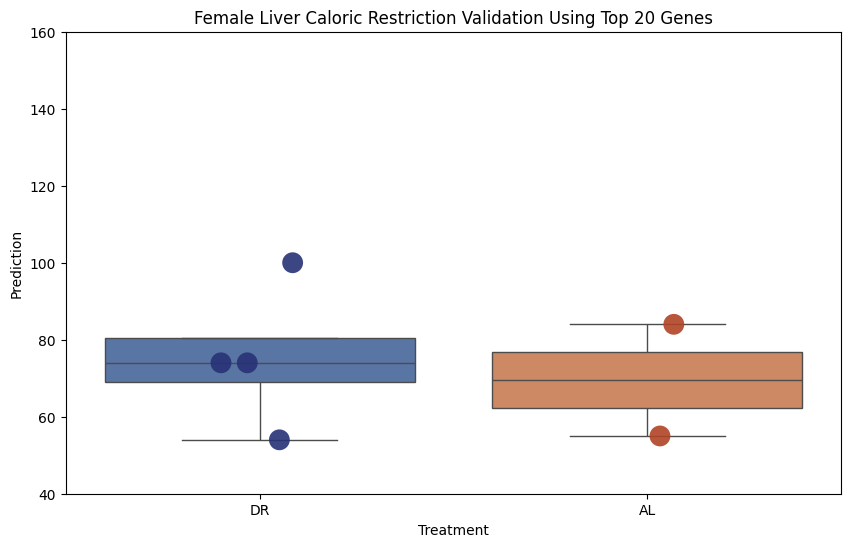

In [ ]:
# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='treatment', y='prediction', hue='treatment', data=df_intervention_test_pred, palette='deep', showfliers = False)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='treatment',
    y='prediction',
    hue='treatment',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join(['Female Liver Caloric Restriction Validation Using Top ', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

# Show the plot
plt.show()

In [ ]:
df_intervention_test_pred.to_csv("./df_prediction_BayesAge_sex_specific_mckay_female.csv", sep="\t")

### Female - rotate training samples

In [ ]:
#------------------------------------------------------------
# Sample selection setup
#------------------------------------------------------------
#select two AL samples for calibration
all_samples = df_intervention_female.index
AL_samples = [s for s in all_samples if s in df_intervention_female.index and df_intervention_female.loc[s, 'treatment'] == 'AL']

# Create all combinations of AL samples
AL_combos = list(itertools.combinations(AL_samples, 2))

#------------------------------------------------------------
# Loop through all young-old combinations
#------------------------------------------------------------
for AL_combo in AL_combos:

  combo_id = f"{'_'.join(map(str, AL_combo))}"
  print(f"\nRunning combo: {combo_id}")

  # Select samples for training
  select_train_samples = list(AL_combo)
  df_intervention_train = df_intervention_female.loc[select_train_samples]
  df_intervention_train = df_intervention_train[tissue_df_counts.columns]  # match columns

  # Combine with atlas
  atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
  age_steps = sorted(atlas_plus_intervention["age"].value_counts().index.tolist())

  atlas_plus_intervention = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-1, -3, -4]], axis=1)

  # Get test set
  test_samples = [s for s in df_intervention_female.index if s not in select_train_samples]
  df_intervention_test = df_intervention_female.loc[test_samples]
  df_intervention_test_counts = df_intervention_test.drop(
      df_intervention_test.columns[[-2, -3, -4, -5]], axis=1
  )

  #check cols ordered the same
  df_intervention_test_counts = df_intervention_test_counts[atlas_plus_intervention.columns]
  df_intervention_test_counts.head(2)

  # Save per-sample reference files
  for sample in atlas_plus_intervention.index:
      atlas_plus_intervention.drop(sample).to_csv(
          f"./reference/liver_sample_{sample}_{combo_id}.csv", sep="\t"
      )

  new_age_steps = np.arange(min(age_steps), max(age_steps) + 1, 1)


  # Run transcriptome_reference (assuming it handles saving internally)
  transcriptome_reference(
      training_matrix=atlas_plus_intervention,
      reference_name=f"killifish_liver_ref_female_{combo_id}",
      output_path="./reference_exhaustive/",
      age_prediction="list",
      age_list=new_age_steps,
      min_age=1,
      max_age=24,
      age_step=1,
      tau=0.7
  )


  # Run predictions for a single gene number or loop over multiple
  for gene_number in range(5, 51, 5):
      df_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])
      reference_df = pd.read_csv(
          f"./reference_exhaustive/killifish_liver_ref_female_{combo_id}", sep="\t", index_col=0
      )
      top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

      for sample in df_intervention_test.index:
          total_reads = df_intervention_test_counts.loc[sample].sum()
          log_sums = []
          for age in new_age_steps:
              logP = []
              for gene in top_genes:
                  freq = max(reference_df.loc[gene, str(age)], 1e-10)
                  mu = freq * total_reads
                  obs = df_intervention_test_counts.loc[sample, gene]
                  p = max(poisson.pmf(obs, mu), 0.001)
                  logP.append(np.log(p))
              log_sums.append(np.sum(logP))

          pred_age = round(float(new_age_steps[np.argmax(log_sums)]), 2)
          df_pred.loc[sample, "prediction"] = pred_age

      # Add metadata and save
      df_pred["treatment"] = df_intervention_test["treatment"]

      # Save prediction results
      df_pred.to_csv(
          f"./predictions_exhaustive/female_pred_top_{gene_number}_{combo_id}.tsv", sep="\t"
      )



Running combo: f_AL_L_1_f_AL_L_2


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_liver_ref_female_f_AL_L_1_f_AL_L_2'
Report file generated at './reference_exhaustive/killifish_liver_ref_female_f_AL_L_1_f_AL_L_2.report.txt'
-----------------------------------------------------



Time to run construct reference: 111.411 seconds

The reference is constructed and saved!

Running combo: f_AL_L_1_f_AL_L_3


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_liver_ref_female_f_AL_L_1_f_AL_L_3'
Report file generated at './reference_exhaustive/killifish_liver_ref_female_f_AL_L_1_f_AL_L_3.report.txt'
-----------------------------------------------------



Time to run construct reference: 103.256 seconds

The reference is constructed and saved!

Running combo: f_AL_L_1_f_AL_L_4


...


Reference model dataset written to './reference_exhaustive/killifish_liver_ref_female_f_AL_L_2_f_AL_L_3'
Report file generated at './reference_exhaustive/killifish_liver_ref_female_f_AL_L_2_f_AL_L_3.report.txt'
-----------------------------------------------------



Time to run construct reference: 103.069 seconds

The reference is constructed and saved!

Running combo: f_AL_L_2_f_AL_L_4


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_liver_ref_female_f_AL_L_2_f_AL_L_4'
Report file generated at './reference_exhaustive/killifish_liver_ref_female_f_AL_L_2_f_AL_L_4.report.txt'
-----------------------------------------------------



Time to run construct reference: 105.756 seconds

The reference is constructed and saved!

Running combo: f_AL_L_3_f_AL_L_4


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_liver_ref_female_f_AL_L_3_f_AL_L_4'
Report file generated at './reference_exhaustive/killifish_liver_ref_female_f_AL_L_3_f_AL_L_4.report.txt'
-----------------------------------------------------



Time to run construct reference: 102.812 seconds

The reference is constructed and saved!
